# Notebook 3: Collaborative Filtering (Baseline 2)
Χρησιμοποιούμε **SVD (Matrix Factorization)** μέσω της `scikit-surprise` library.

In [1]:
import pandas as pd
import numpy as np
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 1. Φόρτωση Δεδομένων

In [2]:
train  = pd.read_csv('../data/train.csv')
test   = pd.read_csv('../data/test.csv')
movies = pd.read_csv('../data/movies.csv')

print('Train:', train.shape, '| Test:', test.shape)

Train: (800167, 4) | Test: (200042, 4)


## 2. Προετοιμασία για Surprise
Η `surprise` library χρειάζεται τα δεδομένα σε δικό της format.

In [3]:
reader = Reader(rating_scale=(1, 5))

# Full dataset για cross-validation
full_data = Dataset.load_from_df(
    train[['user_id','item_id','rating']], reader
)

# Trainset από το train CSV
trainset = full_data.build_full_trainset()

print('Surprise trainset έτοιμο.')

Surprise trainset έτοιμο.


## 3. SVD Εκπαίδευση
SVD με **100 latent factors**, learning rate 0.005, regularization 0.02.

In [4]:
svd = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)

print('Εκπαίδευση SVD (3-fold CV για αξιολόγηση)...')
cv_results = cross_validate(svd, full_data, measures=['RMSE','MAE'], cv=3, verbose=False)

print(f'CV RMSE: {cv_results["test_rmse"].mean():.4f} ± {cv_results["test_rmse"].std():.4f}')
print(f'CV MAE:  {cv_results["test_mae"].mean():.4f} ± {cv_results["test_mae"].std():.4f}')

Εκπαίδευση SVD (3-fold CV για αξιολόγηση)...


CV RMSE: 0.8984 ± 0.0015
CV MAE:  0.7072 ± 0.0012


## 4. Εκπαίδευση στο πλήρες train set & αξιολόγηση στο test

In [5]:
print('Εκπαίδευση SVD στο πλήρες train set...')
svd.fit(trainset)

# Predictions στο test set
test = test.copy()
test['cf_pred'] = test.apply(
    lambda row: svd.predict(row['user_id'], row['item_id']).est, axis=1
)
test['cf_pred'] = test['cf_pred'].clip(1, 5)

rmse_cf = np.sqrt(((test['rating'] - test['cf_pred'])**2).mean())
mae_cf  = (test['rating'] - test['cf_pred']).abs().mean()

print(f'\nCollaborative Filtering (SVD) — Test set:')
print(f'  RMSE: {rmse_cf:.4f}')
print(f'  MAE:  {mae_cf:.4f}')

Εκπαίδευση SVD στο πλήρες train set...



Collaborative Filtering (SVD) — Test set:
  RMSE: 0.8784
  MAE:  0.6902


## 5. Precision@K, Recall@K, F1@K

In [6]:
def precision_recall_f1_at_k(test_df, pred_col, k=10, threshold=4.0):
    precisions, recalls = [], []
    for user_id, group in test_df.groupby('user_id'):
        top_k    = set(group.nlargest(k, pred_col)['item_id'].tolist())
        relevant = set(group[group['rating'] >= threshold]['item_id'].tolist())
        if not relevant:
            continue
        hits = len(top_k & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    p  = np.mean(precisions)
    r  = np.mean(recalls)
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    return p, r, f1

results_cf = {}
for k in [5, 10]:
    p, r, f1 = precision_recall_f1_at_k(test, 'cf_pred', k=k)
    results_cf[k] = {'Precision': p, 'Recall': r, 'F1': f1}
    print(f'K={k:2d}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')

K= 5  Precision=0.7917  Recall=0.4404  F1=0.5660


K=10  Precision=0.6866  Recall=0.6387  F1=0.6618


Εκπαίδευση KNN Item-based CF...
Computing the cosine similarity matrix...
Done computing similarity matrix.


KNN Item-based  RMSE: 0.9996  MAE: 0.7791

Εκπαίδευση KNN User-based CF...
Computing the cosine similarity matrix...


Done computing similarity matrix.


KNN User-based  RMSE: 0.9742  MAE: 0.7667


KNN Item K= 5  P=0.7495  R=0.4175  F1=0.5363
KNN User K= 5  P=0.7805  R=0.4363  F1=0.5598


KNN Item K=10  P=0.6620  R=0.6234  F1=0.6421
KNN User K=10  P=0.6759  R=0.6337  F1=0.6542

=== Σύγκριση CF Προσεγγίσεων ===
                              RMSE     MAE  Precision@5  Recall@5    F1@5  Precision@10  Recall@10   F1@10
Μοντέλο                                                                                                   
KNN User-based              0.9742  0.7667       0.7805    0.4363  0.5598        0.6759     0.6337  0.6542
KNN Item-based              0.9996  0.7791       0.7495    0.4175  0.5363        0.6620     0.6234  0.6421
SVD (Matrix Factorization)  0.8784  0.6902       0.7917    0.4404  0.5660        0.6866     0.6387  0.6618


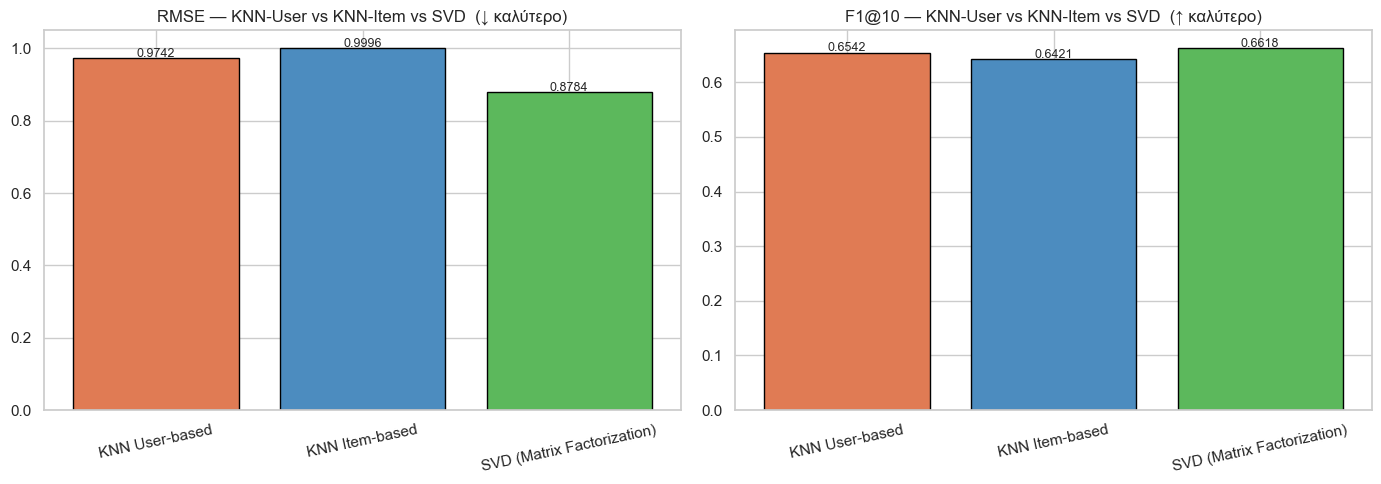

In [7]:
from surprise import KNNBasic

# ── Item-based CF ──────────────────────────────────────────────────────────────
print('Εκπαίδευση KNN Item-based CF...')
knn_item = KNNBasic(k=40, sim_options={'name': 'cosine', 'user_based': False, 'min_support': 5})
knn_item.fit(trainset)

test['knn_item_pred'] = test.apply(
    lambda row: knn_item.predict(row['user_id'], row['item_id']).est, axis=1
).clip(1, 5)

rmse_knn_item = np.sqrt(((test['rating'] - test['knn_item_pred'])**2).mean())
mae_knn_item  = (test['rating'] - test['knn_item_pred']).abs().mean()
print(f'KNN Item-based  RMSE: {rmse_knn_item:.4f}  MAE: {mae_knn_item:.4f}')

# ── User-based CF ──────────────────────────────────────────────────────────────
print('\nΕκπαίδευση KNN User-based CF...')
knn_user = KNNBasic(k=40, sim_options={'name': 'cosine', 'user_based': True, 'min_support': 5})
knn_user.fit(trainset)

test['knn_user_pred'] = test.apply(
    lambda row: knn_user.predict(row['user_id'], row['item_id']).est, axis=1
).clip(1, 5)

rmse_knn_user = np.sqrt(((test['rating'] - test['knn_user_pred'])**2).mean())
mae_knn_user  = (test['rating'] - test['knn_user_pred']).abs().mean()
print(f'KNN User-based  RMSE: {rmse_knn_user:.4f}  MAE: {mae_knn_user:.4f}')

# ── Precision@K, Recall@K, F1@K για KNN ───────────────────────────────────────
results_knn_item, results_knn_user = {}, {}
for k in [5, 10]:
    p, r, f1 = precision_recall_f1_at_k(test, 'knn_item_pred', k=k)
    results_knn_item[k] = {'Precision': p, 'Recall': r, 'F1': f1}
    p, r, f1 = precision_recall_f1_at_k(test, 'knn_user_pred', k=k)
    results_knn_user[k] = {'Precision': p, 'Recall': r, 'F1': f1}
    print(f'KNN Item K={k:2d}  P={results_knn_item[k]["Precision"]:.4f}  R={results_knn_item[k]["Recall"]:.4f}  F1={results_knn_item[k]["F1"]:.4f}')
    print(f'KNN User K={k:2d}  P={results_knn_user[k]["Precision"]:.4f}  R={results_knn_user[k]["Recall"]:.4f}  F1={results_knn_user[k]["F1"]:.4f}')

# ── Σύγκριση KNN-User vs KNN-Item vs SVD ──────────────────────────────────────
cf_comp = pd.DataFrame([
    {'Μοντέλο': 'KNN User-based',
     'RMSE': rmse_knn_user, 'MAE': mae_knn_user,
     'Precision@5':  results_knn_user[5]['Precision'],  'Recall@5':  results_knn_user[5]['Recall'],  'F1@5':  results_knn_user[5]['F1'],
     'Precision@10': results_knn_user[10]['Precision'], 'Recall@10': results_knn_user[10]['Recall'], 'F1@10': results_knn_user[10]['F1']},
    {'Μοντέλο': 'KNN Item-based',
     'RMSE': rmse_knn_item, 'MAE': mae_knn_item,
     'Precision@5':  results_knn_item[5]['Precision'],  'Recall@5':  results_knn_item[5]['Recall'],  'F1@5':  results_knn_item[5]['F1'],
     'Precision@10': results_knn_item[10]['Precision'], 'Recall@10': results_knn_item[10]['Recall'], 'F1@10': results_knn_item[10]['F1']},
    {'Μοντέλο': 'SVD (Matrix Factorization)',
     'RMSE': rmse_cf, 'MAE': mae_cf,
     'Precision@5':  results_cf[5]['Precision'],  'Recall@5':  results_cf[5]['Recall'],  'F1@5':  results_cf[5]['F1'],
     'Precision@10': results_cf[10]['Precision'], 'Recall@10': results_cf[10]['Recall'], 'F1@10': results_cf[10]['F1']},
])

print('\n=== Σύγκριση CF Προσεγγίσεων ===')
print(cf_comp.set_index('Μοντέλο').round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E07B54', '#4C8CBF', '#5CB85C']

axes[0].bar(cf_comp['Μοντέλο'], cf_comp['RMSE'], color=colors, edgecolor='black')
axes[0].set_title('RMSE — KNN-User vs KNN-Item vs SVD  (↓ καλύτερο)')
axes[0].tick_params(axis='x', rotation=12)
for i, v in enumerate(cf_comp['RMSE']):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(cf_comp['Μοντέλο'], cf_comp['F1@10'], color=colors, edgecolor='black')
axes[1].set_title('F1@10 — KNN-User vs KNN-Item vs SVD  (↑ καλύτερο)')
axes[1].tick_params(axis='x', rotation=12)
for i, v in enumerate(cf_comp['F1@10']):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/05b_cf_methods_comparison.png', dpi=150)
plt.show()

Εκπαίδευση KNN User-based (Pearson)...
Computing the pearson similarity matrix...


Done computing similarity matrix.


KNN Pearson (user)  RMSE: 0.9612  MAE: 0.7649

Υπολογισμός Jaccard similarity matrix...


Jaccard matrix: (6040, 6040)


Υπολογισμός Jaccard predictions στο test set...


KNN Jaccard (user)  RMSE: 0.9705  MAE: 0.7729



=== Cosine vs Pearson vs Jaccard vs SVD ===
                        RMSE     MAE  Precision@10  Recall@10   F1@10
Μέθοδος                                                              
KNN User (Cosine)     0.9742  0.7667        0.6759     0.6337  0.6542
KNN User (Pearson)    0.9612  0.7649        0.6772     0.6344  0.6551
KNN User (Jaccard)    0.9705  0.7729        0.6773     0.6338  0.6549
SVD (Latent Factors)  0.8784  0.6902        0.6866     0.6387  0.6618


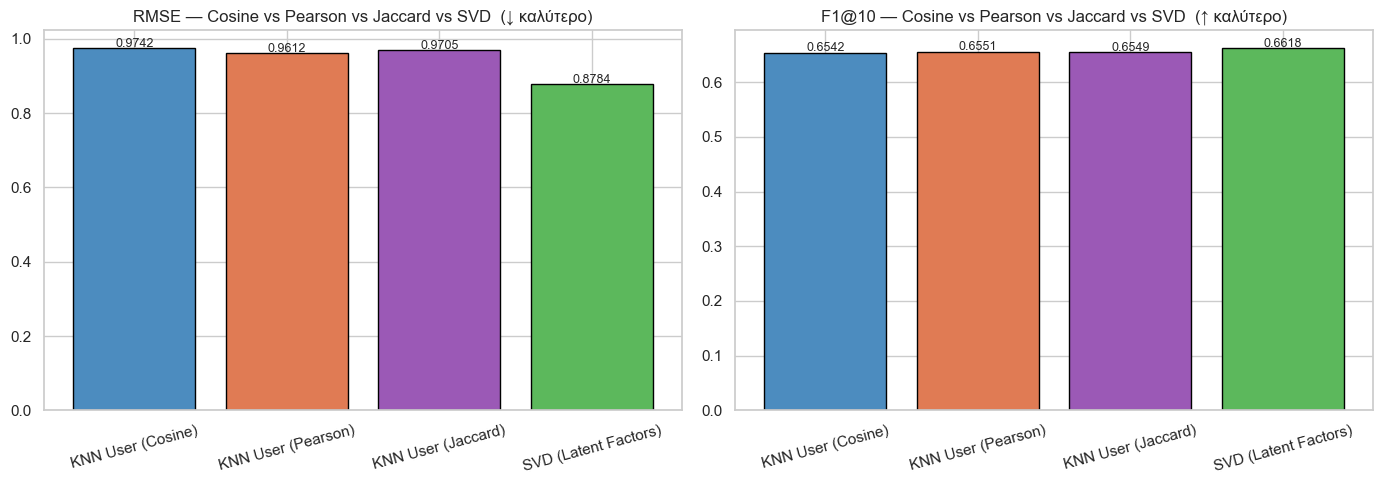

In [8]:
from scipy.sparse import csr_matrix

# ── KNN User-based με Pearson (built-in surprise) ─────────────────────────────
print('Εκπαίδευση KNN User-based (Pearson)...')
knn_pearson = KNNBasic(k=40, sim_options={'name': 'pearson', 'user_based': True, 'min_support': 5})
knn_pearson.fit(trainset)

test['knn_pearson_pred'] = test.apply(
    lambda row: knn_pearson.predict(row['user_id'], row['item_id']).est, axis=1
).clip(1, 5)

rmse_pearson = np.sqrt(((test['rating'] - test['knn_pearson_pred'])**2).mean())
mae_pearson  = (test['rating'] - test['knn_pearson_pred']).abs().mean()
print(f'KNN Pearson (user)  RMSE: {rmse_pearson:.4f}  MAE: {mae_pearson:.4f}')

# ── KNN User-based με Jaccard (custom sparse) ─────────────────────────────────
print('\nΥπολογισμός Jaccard similarity matrix...')

users_list = sorted(train['user_id'].unique())
items_list = sorted(train['item_id'].unique())
user_idx_j = {u: i for i, u in enumerate(users_list)}
item_idx_j = {it: i for i, it in enumerate(items_list)}

rows_i = [user_idx_j[u]  for u in train['user_id']]
cols_i = [item_idx_j[it] for it in train['item_id']]
M = csr_matrix(([1]*len(train), (rows_i, cols_i)),
               shape=(len(users_list), len(items_list)), dtype=np.float32)

# Jaccard: |A ∩ B| / |A ∪ B|  (binary co-ratings)
intersection = (M @ M.T).toarray()
n_rated      = np.array(M.sum(axis=1)).flatten()
union        = n_rated[:, None] + n_rated[None, :] - intersection
jacc_sim     = np.where(union > 0, intersection / union, 0).astype(np.float32)
np.fill_diagonal(jacc_sim, 0)
print(f'Jaccard matrix: {jacc_sim.shape}')

# Lookup: item → [(user, rating)]
item_raters = train.groupby('item_id').apply(
    lambda df: list(zip(df['user_id'], df['rating']))
).to_dict()

GLOBAL_MEAN_CF = train['rating'].mean()

def jaccard_predict(user_id, item_id, k=40):
    if user_id not in user_idx_j or item_id not in item_raters:
        return GLOBAL_MEAN_CF
    u = user_idx_j[user_id]
    candidates = [(jacc_sim[u, user_idx_j[uid]], r)
                  for uid, r in item_raters[item_id]
                  if uid != user_id and uid in user_idx_j]
    if not candidates:
        return GLOBAL_MEAN_CF
    candidates.sort(key=lambda x: -x[0])
    top_k = candidates[:k]
    denom = sum(s for s, _ in top_k)
    if denom == 0:
        return GLOBAL_MEAN_CF
    return float(np.clip(sum(s * r for s, r in top_k) / denom, 1, 5))

print('Υπολογισμός Jaccard predictions στο test set...')
test['knn_jacc_pred'] = test.apply(
    lambda row: jaccard_predict(row['user_id'], row['item_id']), axis=1
)

rmse_jacc = np.sqrt(((test['rating'] - test['knn_jacc_pred'])**2).mean())
mae_jacc  = (test['rating'] - test['knn_jacc_pred']).abs().mean()
print(f'KNN Jaccard (user)  RMSE: {rmse_jacc:.4f}  MAE: {mae_jacc:.4f}')

# ── Precision@K, Recall@K, F1@K ───────────────────────────────────────────────
results_pearson, results_jacc = {}, {}
for k in [5, 10]:
    p, r, f1 = precision_recall_f1_at_k(test, 'knn_pearson_pred', k=k)
    results_pearson[k] = {'Precision': p, 'Recall': r, 'F1': f1}
    p, r, f1 = precision_recall_f1_at_k(test, 'knn_jacc_pred', k=k)
    results_jacc[k] = {'Precision': p, 'Recall': r, 'F1': f1}

# ── Σύγκριση Cosine vs Pearson vs Jaccard vs SVD ──────────────────────────────
sim_comp = pd.DataFrame([
    {'Μέθοδος': 'KNN User (Cosine)',
     'RMSE': rmse_knn_user,  'MAE': mae_knn_user,
     'Precision@10': results_knn_user[10]['Precision'],
     'Recall@10':    results_knn_user[10]['Recall'],
     'F1@10':        results_knn_user[10]['F1']},
    {'Μέθοδος': 'KNN User (Pearson)',
     'RMSE': rmse_pearson,   'MAE': mae_pearson,
     'Precision@10': results_pearson[10]['Precision'],
     'Recall@10':    results_pearson[10]['Recall'],
     'F1@10':        results_pearson[10]['F1']},
    {'Μέθοδος': 'KNN User (Jaccard)',
     'RMSE': rmse_jacc,      'MAE': mae_jacc,
     'Precision@10': results_jacc[10]['Precision'],
     'Recall@10':    results_jacc[10]['Recall'],
     'F1@10':        results_jacc[10]['F1']},
    {'Μέθοδος': 'SVD (Latent Factors)',
     'RMSE': rmse_cf,        'MAE': mae_cf,
     'Precision@10': results_cf[10]['Precision'],
     'Recall@10':    results_cf[10]['Recall'],
     'F1@10':        results_cf[10]['F1']},
])

print('\n=== Cosine vs Pearson vs Jaccard vs SVD ===')
print(sim_comp.set_index('Μέθοδος').round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C8CBF', '#E07B54', '#9B59B6', '#5CB85C']

axes[0].bar(sim_comp['Μέθοδος'], sim_comp['RMSE'], color=colors, edgecolor='black')
axes[0].set_title('RMSE — Cosine vs Pearson vs Jaccard vs SVD  (↓ καλύτερο)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(sim_comp['RMSE']):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(sim_comp['Μέθοδος'], sim_comp['F1@10'], color=colors, edgecolor='black')
axes[1].set_title('F1@10 — Cosine vs Pearson vs Jaccard vs SVD  (↑ καλύτερο)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(sim_comp['F1@10']):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/05c_similarity_comparison.png', dpi=150)
plt.show()

## 6. Σύγκριση CB vs CF (μέχρι τώρα)

              Model     RMSE      MAE  Precision@10  Recall@10    F1@10
      Content-Based 1.016183 0.811930      0.607191   0.595650 0.601365
Collaborative (SVD) 0.878385 0.690212      0.686620   0.638748 0.661819


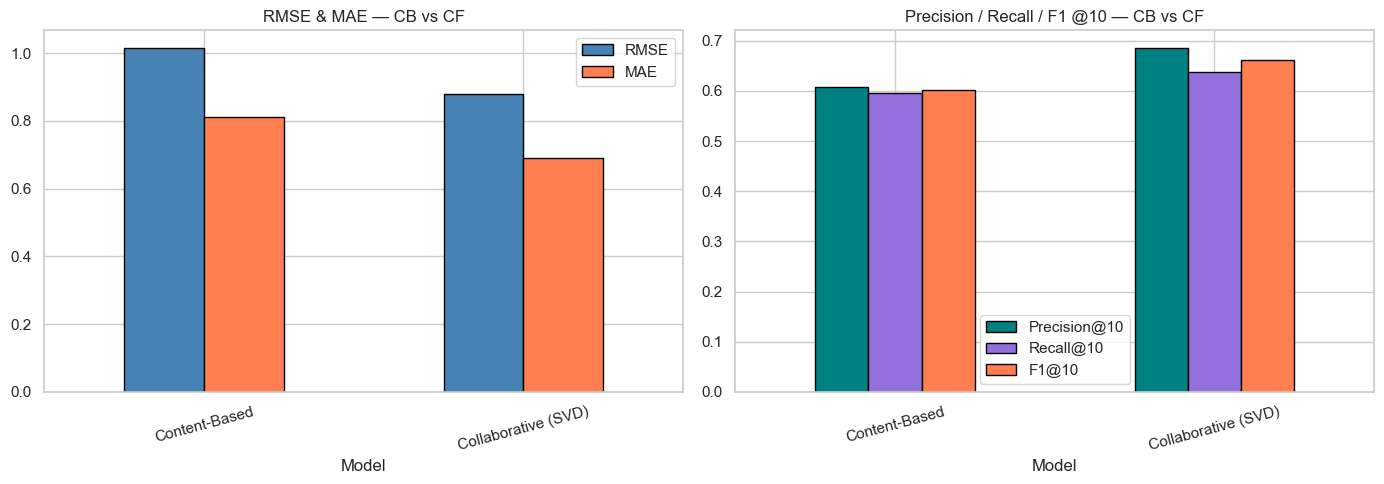

In [9]:
with open('../results/cb_results.json') as f:
    cb_res = json.load(f)

comparison = pd.DataFrame({
    'Model':         ['Content-Based', 'Collaborative (SVD)'],
    'RMSE':          [cb_res['rmse'], rmse_cf],
    'MAE':           [cb_res['mae'], mae_cf],
    'Precision@10':  [cb_res['precision_recall_f1']['10']['Precision'], results_cf[10]['Precision']],
    'Recall@10':     [cb_res['precision_recall_f1']['10']['Recall'],    results_cf[10]['Recall']],
    'F1@10':         [cb_res['precision_recall_f1']['10']['F1'],        results_cf[10]['F1']],
})

print(comparison.to_string(index=False))

# Bar chart σύγκρισης
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison.set_index('Model')[['RMSE','MAE']].plot(
    kind='bar', ax=axes[0], color=['steelblue','coral'], edgecolor='black'
)
axes[0].set_title('RMSE & MAE — CB vs CF')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

comparison.set_index('Model')[['Precision@10','Recall@10','F1@10']].plot(
    kind='bar', ax=axes[1], color=['teal','mediumpurple','coral'], edgecolor='black'
)
axes[1].set_title('Precision / Recall / F1 @10 — CB vs CF')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../results/05_cb_vs_cf.png', dpi=150)
plt.show()

## 7. Αποθήκευση Μοντέλου & Predictions

In [10]:
# Αποθήκευση trained SVD model
with open('../data/svd_model.pkl', 'wb') as f:
    pickle.dump(svd, f)

# Αποθήκευση CF predictions για χρήση στο hybrid
test[['user_id','item_id','rating','cf_pred']].to_csv('../data/test_cf_preds.csv', index=False)

cf_results = {'rmse': rmse_cf, 'mae': mae_cf, 'precision_recall_f1': results_cf}
with open('../results/cf_results.json', 'w') as f:
    json.dump(cf_results, f, indent=2)

print('Model & αποτελέσματα αποθηκεύτηκαν.')

Model & αποτελέσματα αποθηκεύτηκαν.
